In [1]:
# Import libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# PyTorch dataset
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# PyTorch model
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('Training on CPU ...')
else:
    print('Training on GPU ...')

Training on CPU ...


In [3]:
# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 64
# percentage of training set to use as validation
valid_size = 0.2

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
import os


In [24]:

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None, allowed_labels=None):
        """
        Initializes the dataset object.
        :param root_dir: Directory with all the images.
        :param transform: Optional transform to be applied on a sample.
        :param allowed_labels: A list of allowed labels.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.allowed_labels = allowed_labels if allowed_labels is not None else ['prog', 'nonProg']
        self.images = []
        self.label_to_index = self._get_label_to_index()

        for file_name in os.listdir(root_dir):
            label = file_name.split('_')[0]
            if label in self.allowed_labels:
                self.images.append((os.path.join(root_dir, file_name), self.label_to_index[label]))

    def _get_label_to_index(self):
        """Generate a label to index mapping based on allowed labels."""
        label_to_index = {label: index for index, label in enumerate(self.allowed_labels)}
        return label_to_index

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label_index = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label_tensor = torch.tensor(label_index, dtype=torch.long)
        return image, label_tensor


In [25]:
# import os
# import torch
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms

class PTFilesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory containing the .pt files.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.samples = []  # List to store tuples of (sample_path, label)
        self.transform = transform

        # Walk through the root directory and collect all .pt file paths and their labels (filenames)
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.pt'):
                    # Use the filename (without extension) as the label
                    label = os.path.splitext(file)[0]
                    self.samples.append((os.path.join(root, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        sample_path, label = self.samples[idx]
        sample = torch.load(sample_path)  # Load the .pt file

        if self.transform:
            sample = self.transform(sample)

        return sample, label


In [34]:
# Define your transformations (if needed)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Initialize the dataset with your specific input folder
input_folder = '/content/drive/MyDrive/Progect/train'  # Replace with your input folder path
# train_data = PTFilesDataset(input_folder)
# # train_data.size()
# train_data[0][0].size()
train_data = CustomDataset(input_folder,transform)
len(train_data)

394

In [35]:
# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
#split = int(np.floor(valid_size * num_train))
#train_idx, valid_idx = indices[split:], indices[:split]

In [36]:
#Validation Dataset
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Initialize the dataset for validation images
val_dataset = CustomDataset('/content/drive/MyDrive/Progect/validation',transform)
len(val_dataset)


166

In [37]:
# Create DataLoader for the validation dataset
valid_loader = torch.utils.data.DataLoader(val_dataset,batch_size = batch_size, shuffle=False)
len(valid_loader.sampler)

166

In [52]:
#Validation Dataset
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Initialize the dataset for validation images
test_data = CustomDataset('/content/drive/MyDrive/Progect/test',transform)
len(test_data)

45

In [53]:
# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data,batch_size=batch_size, num_workers=num_workers)
len(train_loader.sampler)
# valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
#     sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,num_workers=num_workers)
# len(test_loader.sampler)
# for data,target in train_loader:
#   print(data,target)
len(test_loader.sampler)

45

In [40]:
# specify the image classes
classes = ['prog','nonProg']
classes

['prog', 'nonProg']

In [41]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display
images.shape # (number of examples: 20, number of channels: 3, pixel sizes: 32x32)

(64, 3, 256, 256)

In [42]:
# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # Change 1 to 3 to match RGB input
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 16 * 16, 300)  # Adjust the flattening to match the output size
        self.fc2 = nn.Linear(300, 150)
        self.fc3 = nn.Linear(150, 75)
        self.fc4 = nn.Linear(75, 30)
        self.fc5 = nn.Linear(30, 2)

        # Dropout layer
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Convolutional layers with relu and pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))  # Apply the fourth conv layer

        # Flatten the output for the fully connected layer
        x = x.view(-1, 128 * 16 * 16)  # Adjust the flattening based on the conv4 output

        # Fully connected layers with dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = F.relu(self.fc3(x))  # You forgot to apply relu here
        x = self.dropout(F.relu(self.fc4(x)))  # Apply dropout correctly and relu
        x = self.fc5(x)  # No activation here since it's your output layer, assuming it's for a binary classification

        return x


In [43]:
# create a complete CNN
model = Net()
model

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=150, bias=True)
  (fc3): Linear(in_features=150, out_features=75, bias=True)
  (fc4): Linear(in_features=75, out_features=30, bias=True)
  (fc5): Linear(in_features=30, out_features=2, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

In [44]:
# move tensors to GPU if CUDA is available
if train_on_gpu:
    model.cuda()

In [45]:
# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [46]:
# number of epochs to train the model
n_epochs = 30

valid_loss_min = np.Inf # track change in validation loss

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0

    ###################
    # train the model #
    ###################
    model.train()
    for data, target in train_loader:
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss
        train_loss += loss.item()*data.size(0)

    ######################
    # validate the model #
    ######################
    model.eval()
    for data, target in valid_loader:
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss
        valid_loss += loss.item()*data.size(0)

    # calculate average losses
    train_loss = train_loss/len(train_loader.sampler)
    valid_loss = valid_loss/len(valid_loader.sampler)

    # print training/validation statistics
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))

    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model_progect.pt')
        # valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 0.729092 	Validation Loss: 0.686414
Validation loss decreased (inf --> 0.686414).  Saving model ...
Epoch: 2 	Training Loss: 0.704320 	Validation Loss: 0.695259
Validation loss decreased (inf --> 0.695259).  Saving model ...
Epoch: 3 	Training Loss: 0.681926 	Validation Loss: 0.704812
Validation loss decreased (inf --> 0.704812).  Saving model ...
Epoch: 4 	Training Loss: 0.661445 	Validation Loss: 0.714871
Validation loss decreased (inf --> 0.714871).  Saving model ...
Epoch: 5 	Training Loss: 0.643106 	Validation Loss: 0.725374
Validation loss decreased (inf --> 0.725374).  Saving model ...
Epoch: 6 	Training Loss: 0.625922 	Validation Loss: 0.736000
Validation loss decreased (inf --> 0.736000).  Saving model ...
Epoch: 7 	Training Loss: 0.611320 	Validation Loss: 0.746859
Validation loss decreased (inf --> 0.746859).  Saving model ...
Epoch: 8 	Training Loss: 0.598109 	Validation Loss: 0.757871
Validation loss decreased (inf --> 0.757871).  Saving model ...


###  Load the Model with the Lowest Validation Loss

In [47]:
model.load_state_dict(torch.load('model_progect.pt'))

<All keys matched successfully>

In [59]:
# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(2))
class_total = list(0. for i in range(2))
print(len(test_loader))
model.eval()
# iterate over test data
for data, target in test_loader:
    print(len(target.data))
    # move tensors to GPU if CUDA is available
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    # calculate test accuracy for each object class
    for i in range(min(batch_size,len(target.data))):
        print(batch_size)
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(2):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

1
45
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
Test Loss: 1.153514

Test Accuracy of  prog: 100% (10/10)
Test Accuracy of nonProg:  0% ( 0/35)

Test Accuracy (Overall): 22% (10/45)


### Visualize Sample Test Results

64


NameError: name 'imshow' is not defined

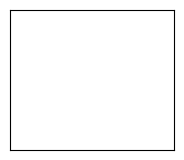

In [60]:
# obtain one batch of test images
dataiter1 = iter(valid_loader)
images, labels = next(dataiter1)
images = images.numpy()


images = torch.from_numpy(images)
print(len(images))
# move model inputs to cuda, if GPU available
if train_on_gpu:
    images = images.cuda()

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(len(images)):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    imshow(images[idx] if not train_on_gpu else images[idx].cpu())
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))